![image info](https://user-images.githubusercontent.com/91945811/146929832-e78ff1f4-2739-41b1-acd3-019a39b6a42c.png)


# 🛠 Feature Engineering – Die Kunst, Daten zu zähmen

## 📌 Was ist Feature Engineering?
Feature Engineering ist eine zentrale Fähigkeit in der Datenanalyse. Es geht darum, Daten sinnvoll zu bereinigen, zu transformieren und neue Merkmale zu erstellen, um aussagekräftige Analysen zu ermöglichen. 🚀

Hier lernst du:
- **Feature Selection** (Merkmale auswählen)
- **Feature Extraction** (Merkmale aus Daten ableiten)
- **Feature Transformation** (Merkmale umwandeln)
- **Feature Creation** (Neue Merkmale erstellen)

Lass uns mit praxisnahen Beispielen durchstarten! 🏁

---

## 1️⃣ Feature Selection – Wichtige Features auswählen
Nicht alle Daten sind relevant. Um gute Analysen zu erstellen, muss man sich auf die wichtigen Merkmale konzentrieren.

### 🔎 Beispiel
Wir nutzen einen einfachen Datensatz, um herauszufinden, welche Merkmale wichtig sind.

In [3]:
import numpy as np
import pandas as pd

# Einfacher Datensatz:
df = pd.DataFrame(
    {
        "Kunde_ID": np.arange(1, 21),
        "Name": ["Kunde_" + str(i) for i in range(1, 21)],
        "Alter": np.random.randint(18, 70, 20),
        "Einkommen": np.random.randint(20000, 100000, 20),
        "Lieblingsfarbe": np.random.choice(["Rot", "Blau", "Grün", "Gelb"], 20),
        "Online_Käufe": np.random.randint(0, 50, 20),
        "Geburtsstadt": np.random.choice(["Berlin", "München", "Hamburg", "Köln"], 20),
        "Kundenzufriedenheit": np.random.randint(1, 11, 20),
    }
)

display(df.head())

,Kunde_ID,Name,Alter,Einkommen,Lieblingsfarbe,Online_Käufe,Geburtsstadt,Kundenzufriedenheit
0,1,Kunde_1,23,44208,Rot,29,Berlin,4
1,2,Kunde_2,51,33418,Gelb,42,Köln,4
2,3,Kunde_3,67,77279,Gelb,13,Köln,1
3,4,Kunde_4,40,98302,Rot,20,Köln,9
4,5,Kunde_5,64,61772,Grün,49,Hamburg,4


### 🎯 Allgemeine Fragestellung für die Datenanalyse:  
**"Welche Faktoren beeinflussen das Kaufverhalten unserer Kunden?"**  

🔍 **Mögliche Analyseansätze:**  
- Wie hängen Alter und Einkommen mit der Anzahl der Online-Käufe zusammen?  
- Gibt es Unterschiede im Kaufverhalten basierend auf der Kundenzufriedenheit?  
- Sind bestimmte Kunden (z. B. ältere oder jüngere) aktiver beim Online-Kauf?  
- Gibt es Muster, die darauf hindeuten, dass bestimmte Kundengruppen häufiger kaufen?  

- **Relevante Spalten:**  
  ✅ Alter, Einkommen, Online_Käufe, Kundenzufriedenheit  
- **Überschüssige/irrelevante Spalten:**  
  ❌ Kunde_ID, Name, Lieblingsfarbe, Geburtsstadt  


In [6]:
# Liste der nicht relevanten Spalten
irrelevante_spalten = ["Kunde_ID", "Name", "Lieblingsfarbe", "Geburtsstadt"]

# Entfernen der nicht relevanten Spalten
df = df.drop(columns=irrelevante_spalten)

df

,Alter,Einkommen,Online_Käufe,Kundenzufriedenheit
0,23,44208,29,4
1,51,33418,42,4
2,67,77279,13,1
3,40,98302,20,9
4,64,61772,49,4
5,68,87412,3,9
6,62,73770,1,9
7,31,71536,27,8
8,27,29863,31,9
9,21,34547,11,7


---

## 2️⃣ Feature Extraction – Neue Infos aus alten Daten
Manchmal steckt in vorhandenen Daten mehr drin, als man denkt! 🧐

### 📌 Beispiel: Extraktion von Datumsinformationen
Angenommen, wir haben eine Spalte mit Zeitstempeln. Daraus können wir zusätzliche Informationen gewinnen:

In [8]:
# Beispieldaten
df = pd.DataFrame({"Bestelldatum": pd.to_datetime(["2023-06-10", "2023-07-15", "2023-08-20"])})

# Neue Features aus dem Datum extrahieren
df["Jahr"] = df["Bestelldatum"].dt.year
df["Monat"] = df["Bestelldatum"].dt.month
df["Wochentag"] = df["Bestelldatum"].dt.day_name()

print("Daten mit extrahierten Features:")
print(df)

Daten mit extrahierten Features:
  Bestelldatum  Jahr  Monat Wochentag
0   2023-06-10  2023      6  Saturday
1   2023-07-15  2023      7  Saturday
2   2023-08-20  2023      8    Sunday


### 📌 Fazit
Durch die Zerlegung des Datums erhalten wir nützliche Informationen für die Analyse, z. B. ob es saisonale Muster gibt.

---

## 3️⃣ Feature Transformation – Damit alles vergleichbar ist
Zahlen haben oft unterschiedliche Größenordnungen. Ein Beispiel: **Alter (z. B. 35 Jahre) und Einkommen (z. B. 50.000€)**. Ohne Skalierung dominiert das Einkommen die Analyse.

### 📌 Beispiel: MinMax-Skalierung

In [10]:
import numpy as np
from sklearn.preprocessing import MinMaxScaler

# Beispiel-Daten
X = np.array([[20, 50000], [35, 70000], [50, 90000]])

# Skalierung anwenden
scaler = MinMaxScaler()
X_scaled = scaler.fit_transform(X)

print("Original:")
print(X)
print("\nNach MinMax-Skalierung:")
print(X_scaled)

Original:
[[   20 50000]
 [   35 70000]
 [   50 90000]]

Nach MinMax-Skalierung:
[[0.  0. ]
 [0.5 0.5]
 [1.  1. ]]


### 📌 Fazit
Jetzt sind **Alter und Einkommen** im gleichen Bereich (0 bis 1) – perfekt für saubere Vergleiche! 👍

---

## 4️⃣ Feature Creation – Kreativ werden!
Du kannst aus vorhandenen Features **neue Features** basteln. Das hilft, wichtige Muster zu finden.

### 📌 Beispiel: Umsatz aus Preis und Anzahl berechnen

In [12]:
# Beispiel-Daten als DataFrame
df = pd.DataFrame({"Preis": [10, 15, 20], "Anzahl": [100, 150, 200]})

# Neues Feature: Umsatz

df["Umsatz"] = df["Preis"] * df["Anzahl"]

print("Daten mit neuem Umsatz-Feature:")
print(df)

Daten mit neuem Umsatz-Feature:
   Preis  Anzahl  Umsatz
0     10     100    1000
1     15     150    2250
2     20     200    4000


### 📌 Fazit
Jetzt haben wir eine wichtige neue Info: **Den Umsatz!** 🤑

## Numerische Features transformieren


In [15]:
# 1️⃣ Binning: Altersgruppen erstellen
df_age = pd.DataFrame({"Alter": np.random.randint(10, 80, 20)})

# Altersgruppen definieren
bins = [0, 18, 35, 50, 70, 100]
labels = ["1-18", "19-35", "36-50", "51-70", "70+"]
df_age["Altersgruppe"] = pd.cut(df_age["Alter"], bins=bins, labels=labels, right=True)
df_age

,Alter,Altersgruppe
0,44,36-50
1,67,51-70
2,37,36-50
3,37,36-50
4,18,1-18
5,35,19-35
6,20,19-35
7,33,19-35
8,29,19-35
9,15,1-18


In [16]:
# 2️⃣ Polynomiale Features: Preis mit Quadratfunktion erweitern

from sklearn.preprocessing import PolynomialFeatures  # Import für polynomiale Feature-Erweiterung

# Erstellen eines DataFrames mit einer Spalte "Preis", die zufällige Werte zwischen 10 und 100 enthält
df_price = pd.DataFrame({"Preis": np.random.randint(10, 100, 20)})

# Initialisieren der PolynomialFeatures-Transformation mit Grad 2 und ohne Bias-Term (Offset)
poly = PolynomialFeatures(degree=2, include_bias=False)

# Anwenden der Transformation auf die "Preis"-Spalte und Hinzufügen einer neuen Spalte "Preis^2"
df_price[["Preis", "Preis^2"]] = poly.fit_transform(df_price[["Preis"]])

# Ausgabe des modifizierten DataFrames
df_price.head()

,Preis,Preis^2
0,24.0,576.0
1,82.0,6724.0
2,17.0,289.0
3,86.0,7396.0
4,64.0,4096.0


Wenn du nur eine Spalte hast, kannst du einfach `df["Preis^2"] = df["Preis"] * df["Preis"]` rechnen.
Aber wenn du mit mehreren Variablen oder höheren Graden arbeitest, macht PolynomialFeatures alles automatisch und spart viel Arbeit! 😊

In [18]:
# 3️⃣ Interaktionsvariablen: Fläche × Preis pro Quadratmeter
df_house = pd.DataFrame(
    {"Fläche_m2": np.random.randint(20, 200, 20), "Preis_pro_m2": np.random.randint(500, 5000, 20)}
)
df_house["Gesamtpreis"] = df_house["Fläche_m2"] * df_house["Preis_pro_m2"]
df_house

,Fläche_m2,Preis_pro_m2,Gesamtpreis
0,179,1490,266710
1,94,2339,219866
2,146,3577,522242
3,33,1391,45903
4,97,1894,183718
5,164,2550,418200
6,145,4519,655255
7,189,2276,430164
8,186,3819,710334
9,147,2741,402927


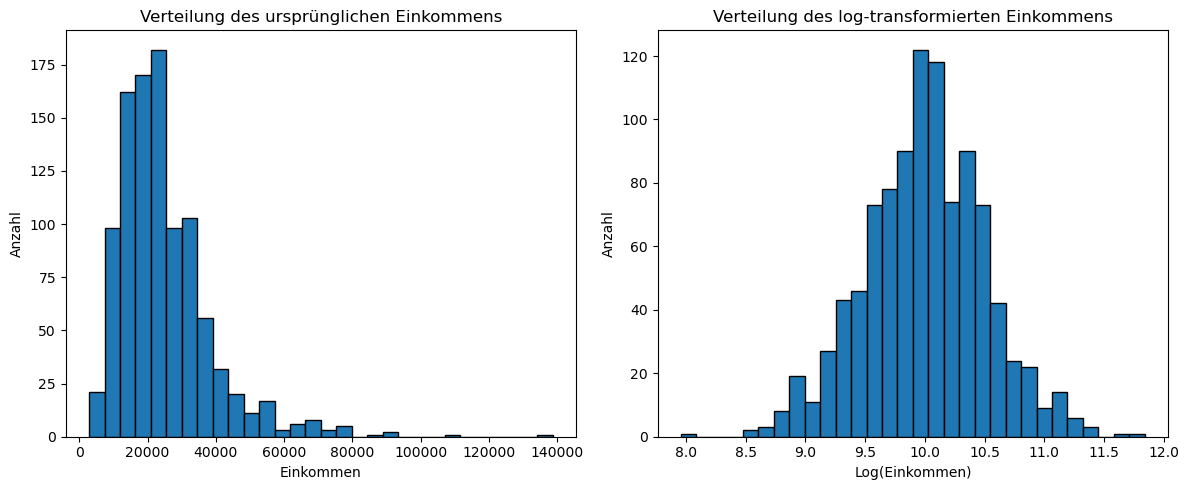

In [19]:
# 4️⃣ Log-Transformation: Einkommen
# Erstellen eines Einkommens-Datensatzes mit einer rechtsschiefen Verteilung
# Statt einer gleichmäßigen Verteilung nehmen wir eine log-normalverteilte Verteilung, die realistischer für Einkommen ist
income_data = np.random.lognormal(
    mean=10, sigma=0.5, size=1000
)  # Skaliert für eine typische Einkommensverteilung

# Erstellen des DataFrames
df_income = pd.DataFrame({"Einkommen": income_data})

# Log-Transformation des Einkommens
df_income["Log_Einkommen"] = np.log(df_income["Einkommen"])

import matplotlib.pyplot as plt

# Erstellen der Plots
plt.figure(figsize=(12, 5))

# Originales Einkommen (rechtsschief)
plt.subplot(1, 2, 1)
plt.hist(df_income["Einkommen"], bins=30, edgecolor="black")
plt.xlabel("Einkommen")
plt.ylabel("Anzahl")
plt.title("Verteilung des ursprünglichen Einkommens")

# Log-transformiertes Einkommen (normaler verteilt)
plt.subplot(1, 2, 2)
plt.hist(df_income["Log_Einkommen"], bins=30, edgecolor="black")
plt.xlabel("Log(Einkommen)")
plt.ylabel("Anzahl")
plt.title("Verteilung des log-transformierten Einkommens")

# Anzeigen der Plots
plt.tight_layout()
plt.show()

Die **Log-Transformation** hat mehrere Vorteile, besonders wenn die Originaldaten **rechtsschief verteilt** sind (wie Einkommen oder Preise). Hier sind die wichtigsten Gründe, warum sie oft verwendet wird:

✅ Wenn die Daten stark **rechtsschief** sind  
✅ Wenn es große **Unterschiede** zwischen kleinen und großen Werten gibt  
✅ Wenn Outlier einen starken Einfluss auf das Modell haben  
✅ Wenn man lineare Methoden auf exponentielle Beziehungen anwenden möchte  

❌ **Wann nicht?**  
🚫 Wenn die Daten bereits normalverteilt sind (unnötig)  
🚫 Wenn die Daten auch **negative oder Nullwerte** enthalten (Log ist nicht definiert für ≤ 0)

Die Log-Transformation ist ein mächtiges Werkzeug, um **Daten besser interpretierbar, robuster und für Machine Learning nutzbarer** zu machen! 🚀

In [21]:
# 5️⃣ Standardisierung/Normalisierung: Körpergrößen & Gewicht
# Notwendige Bibliotheken importieren

from sklearn.preprocessing import StandardScaler

# Erstellen eines DataFrames mit zufälligen Körpergrößen (cm) und Gewichten (kg)
df_health = pd.DataFrame(
    {
        "Größe_cm": np.random.randint(150, 200, 20),  # Zufällige Werte zwischen 150 und 200 cm
        "Gewicht_kg": np.random.randint(50, 100, 20),  # Zufällige Werte zwischen 50 und 100 kg
    }
)

# Standardisierung: Umwandlung der Werte auf Mittelwert 0 und Standardabweichung 1
scaler = StandardScaler()
df_health[["Größe_std", "Gewicht_std"]] = scaler.fit_transform(
    df_health[["Größe_cm", "Gewicht_kg"]]
)

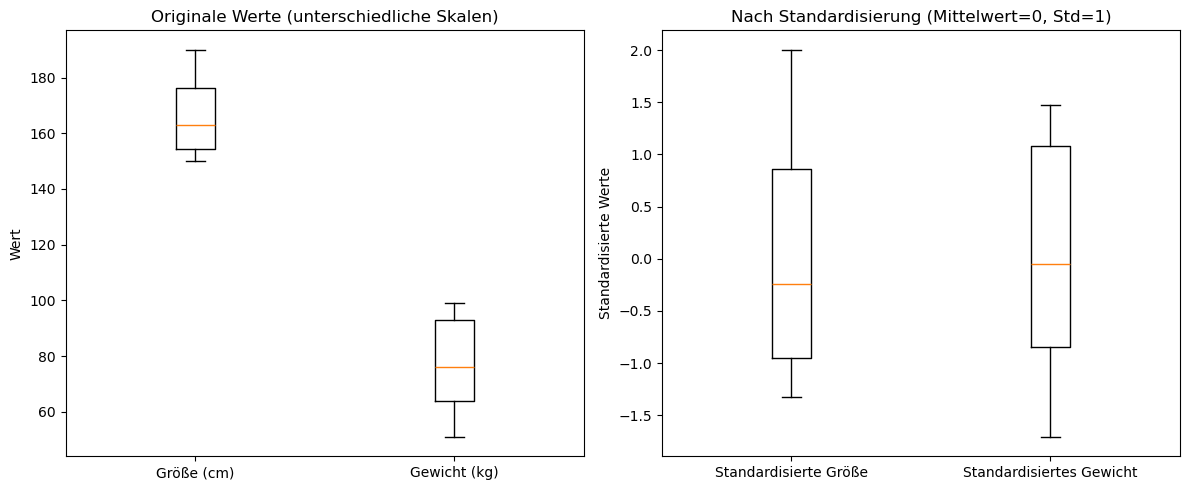

In [22]:
plt.figure(figsize=(12, 5))

# Boxplot der originalen Werte
plt.subplot(1, 2, 1)
plt.boxplot([df_health["Größe_cm"], df_health["Gewicht_kg"]])
plt.xticks([1, 2], ["Größe (cm)", "Gewicht (kg)"])
plt.ylabel("Wert")
plt.title("Originale Werte (unterschiedliche Skalen)")

# Boxplot der standardisierten Werte
plt.subplot(1, 2, 2)
plt.boxplot([df_health["Größe_std"], df_health["Gewicht_std"]])
plt.xticks([1, 2], ["Standardisierte Größe", "Standardisiertes Gewicht"])
plt.ylabel("Standardisierte Werte")
plt.title("Nach Standardisierung (Mittelwert=0, Std=1)")

plt.tight_layout()
plt.show()


### 🔍 **Warum Standardisierung?**
✅ **Vergleichbarkeit**: Größe und Gewicht haben unterschiedliche Einheiten (cm vs. kg), nach der Standardisierung sind sie auf der gleichen Skala.  
✅ **Bessere Performance von Machine-Learning-Modellen**: Viele Modelle (z. B. k-Means, PCA, neuronale Netze) arbeiten besser mit standardisierten Daten.  
✅ **Vermeidung von Verzerrungen**: Große Werte (z. B. Körpergröße) dominieren sonst kleinere Werte (z. B. Gewicht).

---


# Kategorische Features umwandeln

## 🔹 **1. One-Hot-Encoding**  
→ Erstellt für jede Kategorie eine eigene Spalte mit `0` oder `1`.

In [25]:
# Beispiel-Daten: Fahrzeugtypen
df = pd.DataFrame({"Fahrzeugtyp": ["Auto", "LKW", "Motorrad", "Auto", "LKW", "Motorrad"]})

# One-Hot-Encoding mit pandas
df_encoded = pd.get_dummies(df, columns=["Fahrzeugtyp"], prefix="Typ")

display(df)
display(df_encoded)

,Fahrzeugtyp
0,Auto
1,LKW
2,Motorrad
3,Auto
4,LKW
5,Motorrad


,Typ_Auto,Typ_LKW,Typ_Motorrad
0,True,False,False
1,False,True,False
2,False,False,True
3,True,False,False
4,False,True,False
5,False,False,True


➡️ **Vorteil:** Keine numerische Reihenfolge, gut für viele ML-Modelle.  
➡️ **Nachteil:** Kann viele Spalten erzeugen, wenn es viele Kategorien gibt.  

---

## 🔹 **2. Label-Encoding**  
→ Ersetzt jede Kategorie durch eine **Zahl**.

➡️ Beispiel: **Bildungsabschluss** (logische Rangfolge)

In [27]:
# Beispiel-Daten mit einer logischen Reihenfolge
df = pd.DataFrame(
    {
        "Bildungsabschluss": [
            "Kein Abschluss",
            "Hauptschule",
            "Realschule",
            "Abitur",
            "Bachelor",
            "Master",
            "Doktor",
        ]
    }
)

# Manuelle Reihenfolge definieren (von niedrig zu hoch)
bildung_order = [
    "Kein Abschluss",
    "Hauptschule",
    "Realschule",
    "Abitur",
    "Bachelor",
    "Master",
    "Doktor",
]

# Label-Encoding basierend auf der definierten Reihenfolge
df["Bildung_encoded"] = df["Bildungsabschluss"].apply(lambda x: bildung_order.index(x))

print(df)

  Bildungsabschluss  Bildung_encoded
0    Kein Abschluss                0
1       Hauptschule                1
2        Realschule                2
3            Abitur                3
4          Bachelor                4
5            Master                5
6            Doktor                6


---

### **Warum ist das besser?**
✅ **Logische Reihenfolge bleibt erhalten** (höherer Bildungsabschluss = höhere Zahl)  
✅ **Maschinelles Lernen kann Zusammenhänge erkennen** (z. B. höherer Abschluss → höheres Einkommen)  
✅ **Kein Zufall in der Kodierung** wie bei `LabelEncoder()`, wo die Reihenfolge zufällig ist  

**🎯 Tipp:**  
Falls eine Reihenfolge **nicht sinnvoll** ist (z. B. Farben, Städtenamen), sollte man **One-Hot-Encoding oder Frequency-Encoding** nutzen! 🚀

➡️ **Vorteil:** Spart Platz, einfach anzuwenden.  
➡️ **Nachteil:** Modelle könnten die Zahlen als Reihenfolge interpretieren (z. B. "Blau < Grün < Rot"), was nicht immer sinnvoll ist.  

---

## 🔹 **3. Frequency-Encoding**  
→ Ersetzt jede Kategorie durch ihre **Häufigkeit** im Datensatz.

In [30]:
# Beispiel-Daten
df = pd.DataFrame({"Tier": ["Hund", "Katze", "Hund", "Vogel", "Katze", "Katze", "Hund"]})

# Frequency-Encoding
freq_encoding = df["Tier"].value_counts(normalize=True)  # Normalisierung für relative Häufigkeit
df["Tier_encoded"] = df["Tier"].map(freq_encoding)

print(df)

    Tier  Tier_encoded
0   Hund      0.428571
1  Katze      0.428571
2   Hund      0.428571
3  Vogel      0.142857
4  Katze      0.428571
5  Katze      0.428571
6   Hund      0.428571


➡️ **Vorteil:** Erhält eine sinnvolle numerische Darstellung der Kategorien.  
➡️ **Nachteil:** Kann für neue Daten problematisch sein, wenn eine Kategorie vorher nicht im Datensatz vorkam.  

---

## 🔹 **4. Target-Encoding**  
→ Ersetzt jede Kategorie durch den **durchschnittlichen Zielwert** (z. B. mittlerer Hauspreis pro Stadt).  

In [32]:
# Beispiel-Daten: Stadt und Hauspreis
df = pd.DataFrame(
    {
        "Stadt": ["Berlin", "Hamburg", "Berlin", "München", "Hamburg", "München", "Berlin"],
        "Hauspreis": [400000, 500000, 420000, 700000, 520000, 690000, 410000],
    }
)

# Target-Encoding: Durchschnittlicher Hauspreis pro Stadt berechnen
target_encoding = df.groupby("Stadt")["Hauspreis"].mean()
df["Stadt_encoded"] = df["Stadt"].map(target_encoding)

print(df)

     Stadt  Hauspreis  Stadt_encoded
0   Berlin     400000       410000.0
1  Hamburg     500000       510000.0
2   Berlin     420000       410000.0
3  München     700000       695000.0
4  Hamburg     520000       510000.0
5  München     690000       695000.0
6   Berlin     410000       410000.0



➡️ **Vorteil:** Nutzt zusätzliche Informationen aus den Daten (Hauspreis pro Stadt).  
➡️ **Nachteil:** **Leckage-Gefahr**! Wenn nicht korrekt umgesetzt, kann es Informationen aus der Zukunft ins Modell bringen.  

---

### **🎯 Wann welche Methode nutzen?**
| Methode               | Vorteil | Nachteil | Wann nutzen? |
|-----------------------|---------|----------|--------------|
| **One-Hot-Encoding**  | Unabhängige Spalten, gut für ML | Viele Spalten bei vielen Kategorien | Wenn Kategorien **wenige Werte** haben |
| **Label-Encoding**    | Spart Platz, einfach | Modell könnte Reihenfolge falsch interpretieren | Wenn wenige **kategorische Werte** und Reihenfolge irrelevant |
| **Frequency-Encoding** | Berücksichtigt Häufigkeit | Kann bei unbekannten Werten Probleme machen | Wenn Kategorien stark **ungleiche Verteilung** haben |
| **Target-Encoding**   | Nutzt Zielvariable, hilfreich für Vorhersagen | Kann Leckage verursachen | Wenn eine **starke Korrelation** zwischen Kategorie und Ziel existiert |

---

### **Fazit**
Je nach Anwendungsfall ist eine andere Methode besser. **One-Hot-Encoding** ist oft die sicherste Wahl für ML-Modelle, aber bei vielen Kategorien sind **Frequency- oder Target-Encoding** manchmal besser. 🚀